# CV01_Project_카메라 스티커앱 만들기

## 0. 파일설치

In [1]:
!mkdir -p /home/jovyan/work/AIFFEL_quest_eng/Computer_Vision/CV01/camera_sticker/models
!mkdir -p /home/jovyan/work/AIFFEL_quest_eng/Computer_Vision/CV01/camera_sticker/images

In [3]:
!pip install cmake
!pip install opencv-python
!conda install -y dlib

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.1.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [6]:
# 필요한 패키지 import 하기
import os # 환경 변수나 디렉터리, 파일 등의 OS 자원을 제어할 수 있게 해주는 모듈
import cv2 # OpenCV라이브러리 → 컴퓨터 비전 관련 프로그래밍을 쉽게 할 수 있도록 도와주는 라이브러리
import matplotlib.pyplot as plt # 다양한 데이터를 많은 방법으로 도식화 할 수 있도록 하는 라이브러리
import numpy as np # 다차원 배열을 쉽게 처리하고 효율적으로 사용할 수 있도록 하는 라이브러리
import dlib # 이미지 처리 및 기계 학습, 얼굴인식 등을 할 수 있는 c++ 로 개발된 고성능의 라이브러리
print("🌫🛸")

🌫🛸


## 1. 다양한 원본이미지 적용 시 문제점 분석

### 1-1. 얼굴각도에 의한 영향

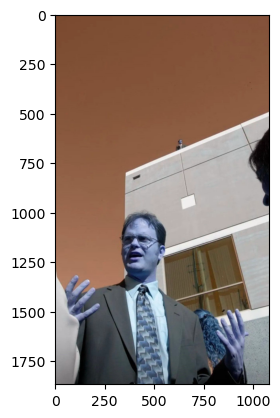

In [8]:
home_dir = os.getenv('HOME')
my_image_path = os.path.join(home_dir, '/home/jovyan/work/AIFFEL_quest_eng/Computer_Vision/CV01/camera_sticker/models/1.jpg')
img_bgr_original = cv2.imread(my_image_path)  # 원본 보관
img_show = img_bgr_original.copy()
plt.imshow(img_bgr_original)
plt.show()

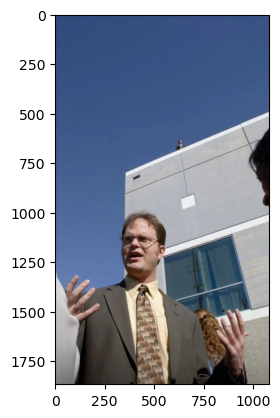

In [9]:
# plt.imshow 이전에 RGB 이미지로 바꾸는 것을 잊지마세요.
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb) # 이미지 실제 출력하기 위해 이미지를 올려줌 (원하는 사이즈의 픽셀을 원하는 색으로 채워서 만든 그림이라고 합니다.)
plt.show() # 이미지 실제 출력

In [10]:
# detector를 선언합니다
detector_hog = dlib.get_frontal_face_detector() # 기본 얼굴 감지기를 반환
print("🌫🛸")

🌫🛸


In [11]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
dlib_rects = detector_hog(img_rgb, 1)   # (image, num of image pyramid)
print("🌫🛸")

🌫🛸


rectangles[[(291, 1059) (513, 1282)]]


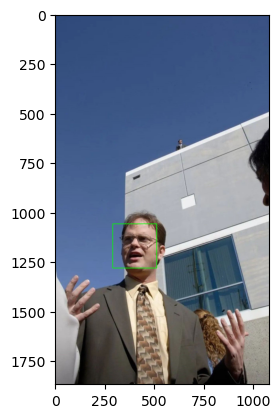

In [12]:
# 찾은 얼굴 영역 박스 리스트
# 여러 얼굴이 있을 수 있습니다
print(dlib_rects)

for dlib_rect in dlib_rects: # 찾은 얼굴 영역의 좌표
    l = dlib_rect.left() # 왼쪽
    t = dlib_rect.top() # 위쪽
    r = dlib_rect.right() # 오른쪽
    b = dlib_rect.bottom() # 아래쪽

    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA) # 시작점의 좌표와 종료점 좌표로 직각 사각형을 그림

img_show_rgb =  cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

In [13]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!mv shape_predictor_68_face_landmarks.dat.bz2 ~/work/camera_sticker/models
!cd ~/work/camera_sticker && bzip2 -d ./models/shape_predictor_68_face_landmarks.dat.bz2

--2026-02-06 05:38:50--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-02-06 05:38:50--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  16.7MB/s    in 4.7s    

2026-02-06 05:38:56 (13.0 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

bzip2: Output file ./models/shape_predictor_68_face_landmarks.dat already exists.


In [14]:
model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')
    # 저장한 landmark 모델의 주소를 model_path 변수에 저장
landmark_predictor = dlib.shape_predictor(model_path)
    # dlib 라이브러리의 shape_predictor 함수를 이용하여 모델을 불러옴
    # landmark_predictor는 RGB이미지와 dlib.rectangle를 입력 받고 dlib.full_object_detection를 반환
    # dlib.rectangle: 내부를 예측하는 박스
    # dlib.full_object_detection: 각 구성 요소의 위치와, 이미지 상의 객체의 위치를 나타냄
print("🌫🛸")

🌫🛸


In [15]:
list_landmarks = []
    # 랜드마크의 위치를 저장할 list 생성

# 얼굴 영역 박스 마다 face landmark를 찾아냅니다
# face landmark 좌표를 저장해둡니다
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
        # 모든 landmark의 위치정보를 points 변수에 저장
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
        # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
    list_landmarks.append(list_points)
        # list_landmarks에 랜드마크 리스트를 저장

print(len(list_landmarks[0]))
    # 얼굴이 n개인 경우 list_landmarks는 n개의 원소를 갖고
    # 각 원소는 68개의 랜드마크 위치가 나열된 list
    # list_landmarks의 원소가 1개이므로 list_landmarks[1]을 호출하면 IndexError가 발생

68


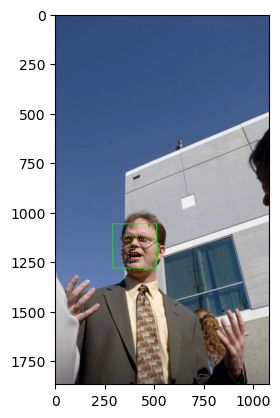

In [16]:
# list_landmarks의 원소가 1개이므로 아래 반복문은 한번만 실행됨
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)
            # cv2.circle: OpenCV의 원을 그리는 함수
            # img_show 이미지 위 각각의 point에
            # 크기가 2이고 (0, 255, 255)색으로 내부가 채워진(-1) 원을 그림
            # (마지막 인수가 자연수라면 그만큼의 두께의 선으로 원이 그려짐)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
    # RGB 이미지로 전환
plt.imshow(img_show_rgb)
    # 이미지를 준비
plt.show()
    # 이미지를 출력

In [17]:
# zip() : 두 그룹의 데이터를 서로 엮어주는 파이썬의 내장 함수
# dlib_rects와 list_landmarks 데이터를 엮어 주었음
# dlib_rects : 얼굴 영역을 저장하고 있는 값
# → rectangles[[(345, 98) (531, 284)]]
# list_landmarks : 68개의 랜드마크 값 저장(이목구비 위치(x,y))
# → [[(368, 153), (368, 174), (371, 195), (376, 215), (382, 235), (391, 252), (404, 266), (420, 277), (441, 279), (461, 276), (480, 266), (495, 252), (508, 235), (516, 216), (520, 195), (523, 173), (524, 151), (377, 131), (386, 119), (399, 116), (413, 118), (425, 124), (454, 121), (466, 114), (481, 112), (494, 114), (503, 127), (439, 143), (438, 156), (438, 169), (437, 182), (423, 197), (431, 199), (438, 200), (446, 199), (454, 197), (391, 147), (399, 142), (409, 143), (416, 149), (408, 150), (399, 150), (464, 147), (472, 141), (482, 141), (489, 145), (482, 149), (473, 149), (411, 227), (421, 222), (432, 218), (439, 220), (446, 218), (458, 222), (471, 227), (458, 234), (446, 238), (438, 238), (431, 238), (420, 235), (415, 227), (432, 227), (439, 228), (447, 227), (466, 227), (446, 228), (438, 229), (431, 228)]]

for dlib_rect, landmark in zip(dlib_rects, list_landmarks): # 얼굴 영역을 저장하고 있는 값과 68개의 랜드마크를 저장하고 있는 값으로 반복문 실행
    print (landmark[30]) # 코의 index는 30 입니다
    x = landmark[30][0] # 이미지에서 코 부위의 x값
    y = landmark[30][1] - dlib_rect.height()//2 # 이미지에서 코 부위의 y값 - 얼굴 영역의 세로를 차지하는 픽셀의 수//2 → (437, 182-(186+1//2))
    w = h = dlib_rect.width() # 얼굴 영역의 가로를 차지하는 픽셀의 수 (531-345+1) → max(x) - min(x) +1(픽셀의 수 이기 때문에 1을 더해줌 → 픽셀 수는 점 하나로도 1이 됨)
    print (f'(x,y) : ({x},{y})')
    print (f'(w,h) : ({w},{h})')

(391, 1159)
(x,y) : (391,1047)
(w,h) : (223,223)


In [18]:
sticker_path = os.path.join(home_dir, 'work/camera_sticker/images/king.png') # 왕관 이미지의 경로
img_sticker = cv2.imread(sticker_path) # 스티커 이미지를 불러옵니다 // cv2.imread(이미지 경로) → image객체 행렬을 반환
img_sticker = cv2.resize(img_sticker, (w,h)) # 스티커 이미지 조정 → w,h는 얼굴 영역의 가로를 차지하는 픽셀의 수(187) // cv2.resize(image객체 행렬, (가로 길이, 세로 길이))
print (img_sticker.shape) # 사이즈를 조정한 왕관 이미지의 차원 확인

(223, 223, 3)


In [19]:
# x,y,w,h 모두 위에서 반복문 안에서 지정해준 값임
# x는 이미지에서 코 부위의 x값 = 437
# y는 이미지에서 코 부위의 y값 = 89
# w는 얼굴 영역의 가로를 차지하는 픽셀의 수 = 187
# h는 얼굴 영역의 가로를 차지하는 픽셀의 수 = 187
refined_x = x - w // 2 # 437 - (187//2) = 437-93 = 344
refined_y = y - h # 89-187 = -98
# 원본 이미지에 스티커 이미지를 추가하기 위해서 x, y 좌표를 조정합니다. 이미지 시작점은 top-left 좌표이기 때문입니다.
# 즉, refined_x, refined_y값에서 왕관 이미지가 시작됨
print (f'(x,y) : ({refined_x},{refined_y})') # 음수 발생 : 이미지 범위를 벗어남
# 우리는 현재 이마 자리에 왕관을 두고 싶은건데, 이마위치 - 왕관 높이를 했더니 이미지의 범위를 초과하여 음수가 나오는 것
# opencv는 ndarray데이터를 사용하는데, ndarray는 음수인덱스에 접근 불가하므로 스티커 이미지를 잘라 줘야 한다.

(x,y) : (280,824)


In [20]:
# 왕관 이미지가 이미지 밖에서 시작하지 않도록 조정이 필요함
# 좌표 순서가 y,x임에 유의한다. (y,x,rgb channel)
# 현재 상황에서는 -y 크기만큼 스티커를 crop 하고, top 의 x좌표와 y 좌표를 각각의 경우에 맞춰 원본 이미지의 경계 값으로 수정하면 아래와 같은 형식으로 나옵니다.
# 음수값 만큼 왕관 이미지(혹은 추후 적용할 스티커 이미지)를 자른다.
if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:]
    refined_x = 0
# 왕관 이미지를 씌우기 위해 왕관 이미지가 시작할 y좌표 값 조정
if refined_y < 0:
    img_sticker = img_sticker[-refined_y:, :] # refined_y가 -98이므로, img_sticker[98: , :]가 된다. (187, 187, 3)에서 (89, 187, 3)이 됨 (187개 중에서 98개가 잘려나감)
    refined_y = 0

print (f'(x,y) : ({refined_x},{refined_y})')

(x,y) : (280,824)


In [21]:
# sticker_area는 원본이미지에서 스티커를 적용할 위치를 crop한 이미지 입니다.
# 예제에서는 (344,0) 부터 (344+187, 0+89) 범위의 이미지를 의미합니다.
# 좌표 순서가 y,x임에 유의한다. (y,x,rgb channel)
# img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
# img_show[0:0+89, 344:344+187]
# img_show[0:89, 344:531]
# 즉, x좌표는 344~531 / y좌표는 0~89가 됨
sticker_area = img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
# 왕관 이미지에서 사용할 부분은 0이 아닌 색이 있는 부분을 사용합니다.
# 왕관 이미지에서 0이 나오는 부분은 흰색이라는 뜻, 즉 이미지가 없다는 소리임.
# 현재 왕관 이미지에서는 왕관과 받침대 밑의 ------ 부분이 됨
# 그렇기 때문에 0인 부분(이미지가 없는 부분)은 제외하고 적용
# sticker_area는 원본 이미지에서 스티커를 적용할 위치를 미리 잘라낸 이미지입니다.
# 즉, 왕관 이미지에서 왕관 이미지가 없는 부분(왕관과 받침대 밑의 ------ 부분)은 원본 이미지에서 미리 잘라놓은 sticker_area(스티커 적용할 부분 만큼 원본 이미지에서 자른 이미지)를 적용하고,
# 나머지 부분은 스티커로 채워주면 됨
# np.where는 조건에 해당하는 인덱스만 찾아서 값을 적용하는 방법이다.
# 아래 코드에서는 img_sticker가 0일 경우(왕관 이미지에서 왕관 부분 제외한 나머지 이미지)에는 sticker_area(원본 이미지에서 스티커를 적용할 위치를 미리 잘라낸 이미지)를 적용하고,
# 나머지 부분은 img_sticker(왕관 이미지)를 적용한다.
img_show[refined_y:refined_y+img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
    np.where(img_sticker==0,sticker_area,img_sticker).astype(np.uint8)
print("슝~")

슝~


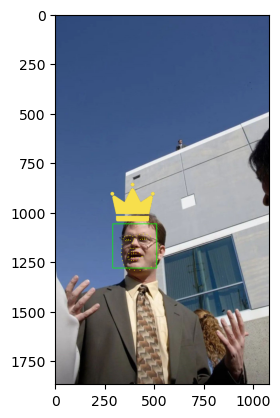

In [22]:
# 왕관 이미지를 적용한 이미지를 보여준다.
# 얼굴 영역(7-3)과 랜드마크(7-4)를 미리 적용해놓은 img_show에 왕관 이미지를 덧붙인 이미지가 나오게 된다.)
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

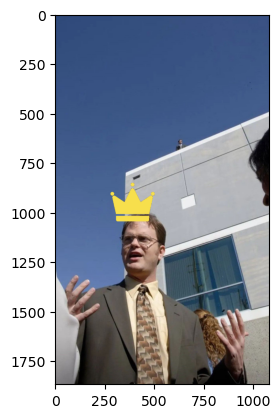

In [23]:
# 위에서 설명했으므로 생략
# 왕관 이미지
sticker_area = img_bgr[refined_y:refined_y +img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
# img_bgr은 7-2에서 rgb로만 적용해놓은 원본 이미지이다.
img_bgr[refined_y:refined_y +img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
    np.where(img_sticker==0,sticker_area,img_sticker).astype(np.uint8)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)) # rgb만 적용해놓은 원본 이미지에 왕관 이미지를 덮어 씌운 이미지가 나오게 된다.
plt.show()

#### 소결

얼굴의 각도가 다른 사람의 이미지를 의도적으로 사용하여 '왕관'이미지 안착의 결과를 관찰하였다. 결과는 '왕관'이미지가 좌측으로 치우쳐져 위치한다. 앞으로는 이 문제를 어떻게 해결할 수 있을지를 논의해보고자 한다.

### 1-2. 얼굴각도 문제 해결(1)

얼굴 각도를 계산하여 스티커를 각도만큼 회전시키는 발상입니다.

얼굴 각도: -4.40도


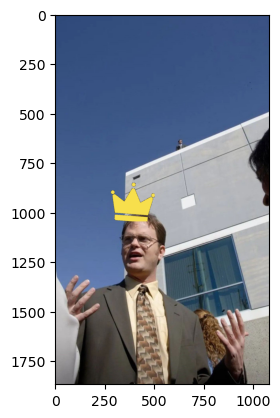

In [36]:
# 원본 이미지 다시 로드
img_bgr = cv2.imread(my_image_path)

import numpy as np
import cv2

def get_face_angle(landmarks):
    # NumPy 배열로 변환
    landmarks = np.array(landmarks)
    
    # 얼굴 회전 각도 계산
    # 양쪽 눈의 중심점 사용
    left_eye = landmarks[36:42]  # 왼쪽 눈
    right_eye = landmarks[42:48]  # 오른쪽 눈
    
    left_eye_center = left_eye.mean(axis=0).astype(int)
    right_eye_center = right_eye.mean(axis=0).astype(int)
    
    # 두 눈 사이의 각도 계산
    dY = right_eye_center[1] - left_eye_center[1]
    dX = right_eye_center[0] - left_eye_center[0]
    angle = np.degrees(np.arctan2(dY, dX))
    
    return angle

def rotate_sticker(img_sticker, angle):
    # 스티커를 각도만큼 회전
    h, w = img_sticker.shape[:2]
    center = (w // 2, h // 2)
    
    # 회전 행렬 생성
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    
    # 회전 적용 (투명도 유지)
    rotated = cv2.warpAffine(img_sticker, M, (w, h), 
                             flags=cv2.INTER_LINEAR,
                             borderMode=cv2.BORDER_CONSTANT,
                             borderValue=(0, 0, 0, 0))
    return rotated

# 기존 위치/크기 계산 방식
for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
    x = landmark[30][0]
    y = landmark[30][1] - dlib_rect.height()//2
    w = h = dlib_rect.width()

refined_x = x - w // 2
refined_y = y - h

# 경계 처리
if refined_x < 0:
    img_sticker = img_sticker[:, -refined_x:]
    refined_x = 0
if refined_y < 0:
    img_sticker = img_sticker[-refined_y:, :]
    refined_y = 0

# 여기서부터 회전 추가
# 얼굴 각도 계산
angle = get_face_angle(list_landmarks[0])
print(f"얼굴 각도: {angle:.2f}도")

# 스티커 회전 적용
img_sticker_rotated = rotate_sticker(img_sticker, angle)

# 회전된 스티커를 리사이즈
img_sticker_resized = cv2.resize(img_sticker_rotated, (w, h))

# 스티커 적용
sticker_area = img_bgr[refined_y:refined_y + img_sticker_resized.shape[0], 
                       refined_x:refined_x + img_sticker_resized.shape[1]]

img_bgr[refined_y:refined_y + img_sticker_resized.shape[0], 
        refined_x:refined_x + img_sticker_resized.shape[1]] = \
    np.where(img_sticker_resized == 0, sticker_area, img_sticker_resized).astype(np.uint8)

plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.show()

#### 소결

스티커가 실제 얼굴 각도처럼 회전하여 더욱 자연스러웠습니다. 그러나 여전히 왼쪽으로 치우쳐진 상황이 해결이 되지 않았습니다. 이를 해결해보는 도전을 해보도록 하겠습니다.

### 1-3. 얼굴각도 문제 해결(2)

30번 코 인덱스를 하여 중심을 사용하는 것이 아닌 양쪽 눈썹의 중심점을 계산하여 '왕관'이미지가 사람의 머리의 중앙으로 올 수 있도록 도전해보겠습니다.

얼굴 각도: -4.40도
왕관 위치: x=300, y=872, 크기=223x223


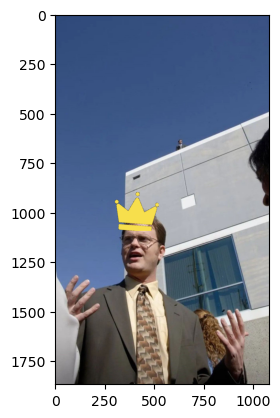

In [37]:
# 원본 이미지 다시 로드
img_bgr = cv2.imread(my_image_path)

# NumPy 배열로 변환
landmarks = np.array(list_landmarks[0])

# 얼굴 각도 계산
angle = get_face_angle(landmarks)
print(f"얼굴 각도: {angle:.2f}도")

# 위치 계산: 양쪽 눈썹 중심 사용 (좌우 중앙 맞춤)
left_eyebrow_center = landmarks[19:22].mean(axis=0).astype(int)   # 왼쪽 눈썹
right_eyebrow_center = landmarks[22:27].mean(axis=0).astype(int)  # 오른쪽 눈썹
eyebrow_center = ((left_eyebrow_center + right_eyebrow_center) / 2).astype(int)

# 크기 계산: 얼굴 전체 너비 사용 (크기 충분하게)
face_width = dlib_rects[0].width()  # 얼굴 너비
w = face_width
h = w

# 왕관 위치: 눈썹 중심 기준, 충분히 위로
refined_x = eyebrow_center[0] - w // 2  # 중심 기준으로 조정
refined_y = eyebrow_center[1] - int(h * 1.1)  # 눈썹 위에 배치 (1.1배 위로)

print(f"왕관 위치: x={refined_x}, y={refined_y}, 크기={w}x{h}")

# 스티커 회전
img_sticker_rotated = rotate_sticker(img_sticker, angle)

# 회전된 스티커를 리사이즈
img_sticker_resized = cv2.resize(img_sticker_rotated, (w, h))

# 경계 처리 (이미지 밖으로 나가는 경우)
if refined_y < 0:
    img_sticker_resized = img_sticker_resized[-refined_y:, :]
    refined_y = 0
if refined_x < 0:
    img_sticker_resized = img_sticker_resized[:, -refined_x:]
    refined_x = 0

# 스티커 적용
sticker_h, sticker_w = img_sticker_resized.shape[:2]
sticker_area = img_bgr[refined_y:refined_y + sticker_h, refined_x:refined_x + sticker_w]

# 크기 체크 후 적용
if sticker_area.shape[:2] == img_sticker_resized.shape[:2]:
    img_bgr[refined_y:refined_y + sticker_h, refined_x:refined_x + sticker_w] = \
        np.where(img_sticker_resized == 0, sticker_area, img_sticker_resized).astype(np.uint8)
else:
    # 크기 불일치 시 조정
    h_min = min(sticker_area.shape[0], img_sticker_resized.shape[0])
    w_min = min(sticker_area.shape[1], img_sticker_resized.shape[1])
    img_bgr[refined_y:refined_y + h_min, refined_x:refined_x + w_min] = \
        np.where(img_sticker_resized[:h_min, :w_min] == 0, 
                 sticker_area[:h_min, :w_min], 
                 img_sticker_resized[:h_min, :w_min]).astype(np.uint8)

plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.show()

### 1-4. 소결

양쪽 눈썹의 중심점을 이용하여 '왕관' 이미지 배치가 될 수 있도록 하였습니다. 얼굴의 각도가 변했을 때의 왕관 위치도 적절하게 배치가 되는 것을 확인할 수 있었습니다.

### 2-1. 이미지 밝기에 의한 영향

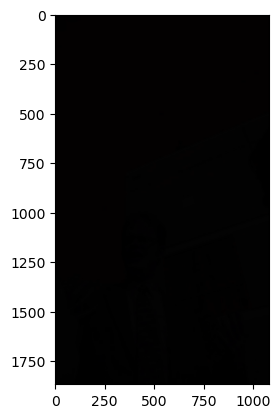

In [63]:
home_dir = os.getenv('HOME')
my_image_path = os.path.join(home_dir, '/home/jovyan/work/AIFFEL_quest_eng/Computer_Vision/CV01/camera_sticker/models/4.jpg')
img_bgr_original = cv2.imread(my_image_path)  # 원본 보관
img_show = img_bgr_original.copy()
plt.imshow(img_bgr_original)
plt.show()

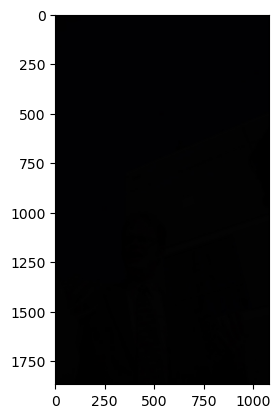

In [64]:
img_rgb = cv2.cvtColor(img_bgr_original, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()

rectangles[]


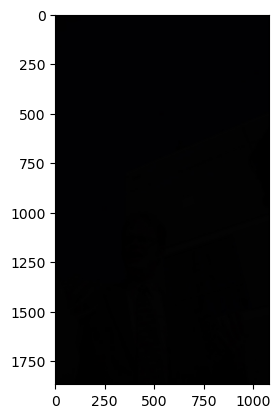

In [65]:
img_rgb = cv2.cvtColor(img_bgr_original, cv2.COLOR_BGR2RGB)
dlib_rects = detector_hog(img_rgb, 1)

# 사각형 그리기
img_show = img_bgr_original.copy()
print(dlib_rects)

for dlib_rect in dlib_rects:
    l = dlib_rect.left()
    t = dlib_rect.top()
    r = dlib_rect.right()
    b = dlib_rect.bottom()
    
    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

이미지 밝기가 어두워 얼굴에 대한 사각형이 그려지지 않는 것을 확인할 수 있다. 그렇다면 어떻게 이 문제를 처리할 수 있을까? 앞으로 이를 해결해보도록 하겠다.

### 2-2. 이미지 밝기 문제 해결(1)

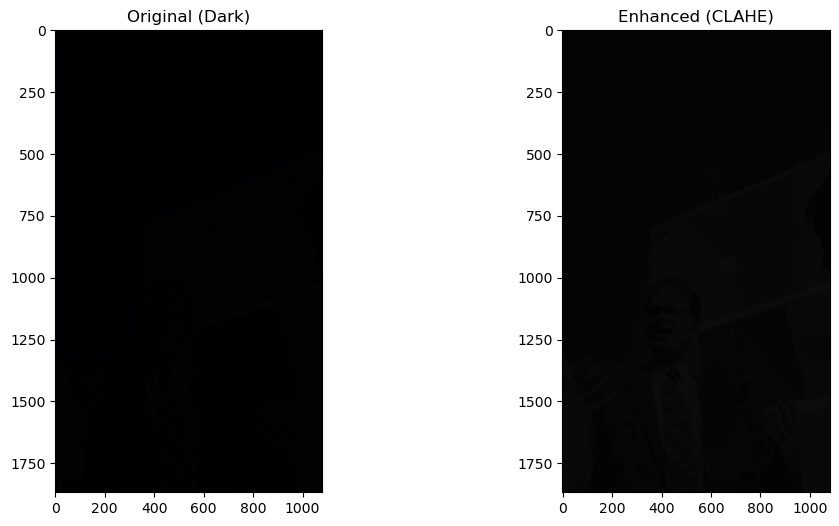

검출된 얼굴: 0개


In [66]:
# 어두운 이미지 밝게 만들기
img_gray = cv2.cvtColor(img_bgr_original, cv2.COLOR_BGR2GRAY)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_enhanced = clahe.apply(img_gray)
img_rgb = cv2.cvtColor(img_enhanced, cv2.COLOR_GRAY2RGB)

# 얼굴 인식
dlib_rects = detector_hog(img_rgb, 1)

# 결과 확인
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img_bgr_original, cv2.COLOR_BGR2RGB))
plt.title('Original (Dark)')
plt.subplot(1,2,2)
plt.imshow(img_rgb)
plt.title('Enhanced (CLAHE)')
plt.show()

print(f"검출된 얼굴: {len(dlib_rects)}개")

[CLAHE의 핵심 작동 원리]

CLAHE는 크게 세 가지 단계로 나누어 이해할 수 있습니다.

- Adaptive (적응형): 이미지를 한 번에 처리하지 않고, '타일(Tile)'이라고 불리는 작은 격자 단위로 나눕니다. 각 구역별로 히스토그램 평활화를 적용하기 때문에, 어두운 부분은 밝게, 밝은 부분은 적절하게 조절하여 지역적인 세부 사항을 살려냅니다.
- Contrast Limited (대비 제한): 단순히 구역별로 평활화를 하면 노이즈(잡음)가 너무 과하게 증폭될 수 있습니다. 이를 막기 위해 특정 임계값(Clip Limit)을 설정하여, 그 이상의 빈도수를 가진 픽셀들을 다른 빈도로 골고루 재분배합니다.
- Interpolation (보간법): 각 타일을 독립적으로 처리하면 경계선이 부자연스럽게 보일 수 있습니다. CLAHE는 bilinear interpolation(쌍선형 보간법)을 사용하여 타일 사이의 경계를 부드럽게 이어줍니다.

CLAHE을 통해 이미지 밝기를 눈이 인식할 수 있을 정도로 개선시켰습니다. 얼굴도 검출된 것을 확인할 수 있습니다. 이제 detection을 해보도록 하겠습니다.

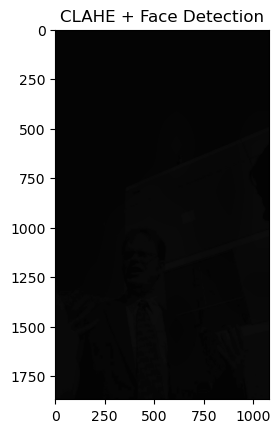

In [67]:
dlib_rects = detector_hog(img_rgb, 1)

# 얼굴에 사각형 그리기
img_show = cv2.cvtColor(img_enhanced, cv2.COLOR_GRAY2BGR)  # BGR로 변환 (사각형 그리기용)

for dlib_rect in dlib_rects:
    l = dlib_rect.left()
    t = dlib_rect.top()
    r = dlib_rect.right()
    b = dlib_rect.bottom()
    
    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA)

# 결과 출력
img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.title('CLAHE + Face Detection')
plt.show()

Dection을 시도했지만 아직도 안되네요. 히스토그램 균등화를 시도해보도록 하겠습니다. 연구해보니 히스토그램 균등화가 CLAHE보다 더 강력하다고 합니다.

### 2-3. 이미지 밝기 문제 해결(2)

히스토그램 균등화: 1개 검출


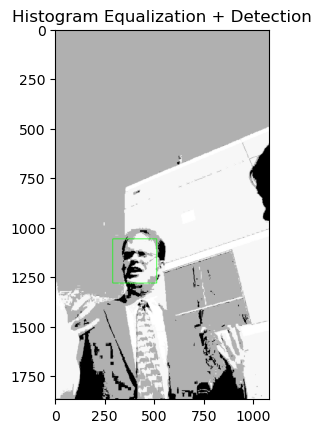

In [68]:
# 히스토그램 균등화 (더 강력한 밝기 보정)
img_gray = cv2.cvtColor(img_bgr_original, cv2.COLOR_BGR2GRAY)
img_equalized = cv2.equalizeHist(img_gray)
img_rgb = cv2.cvtColor(img_equalized, cv2.COLOR_GRAY2RGB)

dlib_rects = detector_hog(img_rgb, 1)
print(f"히스토그램 균등화: {len(dlib_rects)}개 검출")

# 결과 출력
img_show = cv2.cvtColor(img_equalized, cv2.COLOR_GRAY2BGR)
for dlib_rect in dlib_rects:
    l, t, r, b = dlib_rect.left(), dlib_rect.top(), dlib_rect.right(), dlib_rect.bottom()
    cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.title('Histogram Equalization + Detection')
plt.show()

히스토그램 균등화를 하니 Detection이 되었습니다. 이제 '왕관'이미지를 입혀보도록 하겠습니다.

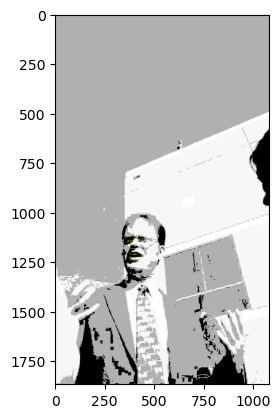

얼굴 각도: -6.71도
왕관 위치: x=296, y=875, 크기=223x223


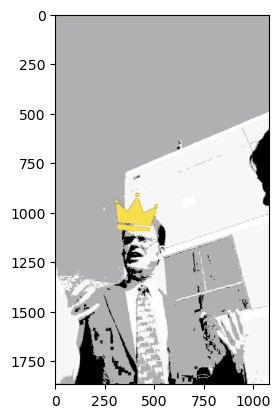

In [88]:
img_path = os.path.join(home_dir, '/home/jovyan/work/AIFFEL_quest_eng/Computer_Vision/CV01/camera_sticker/models/4.jpg')
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_show = img_bgr.copy()

# 히스토그램 균등화 (밝기 개선)
img_ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
img_ycrcb[:, :, 0] = cv2.equalizeHist(img_ycrcb[:, :, 0])
img_bgr = cv2.cvtColor(img_ycrcb, cv2.COLOR_YCrCb2BGR)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_show = img_bgr.copy()

# 얼굴 검출
detector_hog = dlib.get_frontal_face_detector()
dlib_rects = detector_hog(img_rgb, 1)

# 랜드마크 검출
model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')
landmark_predictor = dlib.shape_predictor(model_path)
list_landmarks = []
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    list_landmarks.append(list_points)

# 랜드마크 표시
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

# 왕관 적용은 원본 이미지에 (랜드마크 없이)
img_result = img_bgr.copy()

# NumPy 배열로 변환
landmarks = np.array(list_landmarks[0])

# 얼굴 각도 계산
angle = get_face_angle(landmarks)
print(f"얼굴 각도: {angle:.2f}도")

# 위치 계산: 양쪽 눈썹 중심 사용 (좌우 중앙 맞춤)
left_eyebrow_center = landmarks[19:22].mean(axis=0).astype(int)   # 왼쪽 눈썹
right_eyebrow_center = landmarks[22:27].mean(axis=0).astype(int)  # 오른쪽 눈썹
eyebrow_center = ((left_eyebrow_center + right_eyebrow_center) / 2).astype(int)

# 크기 계산: 얼굴 전체 너비 사용 (크기 충분하게)
face_width = dlib_rects[0].width()  # 얼굴 너비
w = face_width
h = w

# 왕관 위치: 눈썹 중심 기준, 충분히 위로
refined_x = eyebrow_center[0] - w // 2  # 중심 기준으로 조정
refined_y = eyebrow_center[1] - int(h * 1.1)  # 눈썹 위에 배치 (1.1배 위로)

print(f"왕관 위치: x={refined_x}, y={refined_y}, 크기={w}x{h}")

# 스티커 회전
img_sticker_rotated = rotate_sticker(img_sticker, angle)

# 회전된 스티커를 리사이즈
img_sticker_resized = cv2.resize(img_sticker_rotated, (w, h))

# 경계 처리 (이미지 밖으로 나가는 경우)
if refined_y < 0:
    img_sticker_resized = img_sticker_resized[-refined_y:, :]
    refined_y = 0
if refined_x < 0:
    img_sticker_resized = img_sticker_resized[:, -refined_x:]
    refined_x = 0

# 스티커 적용
sticker_h, sticker_w = img_sticker_resized.shape[:2]
sticker_area = img_bgr[refined_y:refined_y + sticker_h, refined_x:refined_x + sticker_w]

# 크기 체크 후 적용
if sticker_area.shape[:2] == img_sticker_resized.shape[:2]:
    img_bgr[refined_y:refined_y + sticker_h, refined_x:refined_x + sticker_w] = \
        np.where(img_sticker_resized == 0, sticker_area, img_sticker_resized).astype(np.uint8)
else:
    # 크기 불일치 시 조정
    h_min = min(sticker_area.shape[0], img_sticker_resized.shape[0])
    w_min = min(sticker_area.shape[1], img_sticker_resized.shape[1])
    img_bgr[refined_y:refined_y + h_min, refined_x:refined_x + w_min] = \
        np.where(img_sticker_resized[:h_min, :w_min] == 0, 
                 sticker_area[:h_min, :w_min], 
                 img_sticker_resized[:h_min, :w_min]).astype(np.uint8)

plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.show()

히스토그램 균등화를 통해 얼굴 검출이 잘 된 것을 확인할 수 있고, 왕관 이미지도 잘 배치된 것을 확인할 수 있습니다. 이제 원본 이미지에 '왕관'이미지를 배치하도록 하겠습니다.

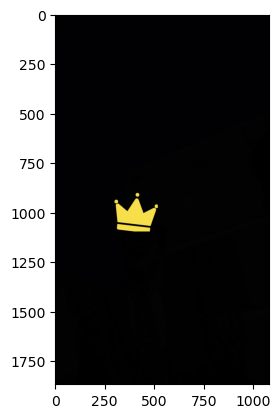

In [90]:
img_path = os.path.join(home_dir, '/home/jovyan/work/AIFFEL_quest_eng/Computer_Vision/CV01/camera_sticker/models/4.jpg')
img_bgr_original = cv2.imread(img_path)
img_result = img_bgr_original.copy()

# 이미 계산된 왕관 위치 사용
# refined_x, refined_y, w, h, angle 값은 이전 셀에서 계산된 값 그대로 사용

# 회전 함수 정의
def rotate_sticker(img, angle):
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img, rotation_matrix, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))
    return rotated

# 스티커 로드
sticker_path = os.path.join(home_dir, 'work/camera_sticker/images/king.png')
img_sticker = cv2.imread(sticker_path)

# 스티커 회전 후 크기 조정
img_sticker_rotated = rotate_sticker(img_sticker, angle)
img_sticker_resized = cv2.resize(img_sticker_rotated, (w, h))

# 경계 처리
sticker_to_apply = img_sticker_resized.copy()
x_offset = 0
y_offset = 0

if refined_x < 0:
    x_offset = -refined_x
    sticker_to_apply = sticker_to_apply[:, x_offset:]
    refined_x = 0
if refined_y < 0:
    y_offset = -refined_y
    sticker_to_apply = sticker_to_apply[y_offset:, :]
    refined_y = 0

# 스티커 적용
sticker_h, sticker_w = sticker_to_apply.shape[:2]
sticker_area = img_result[refined_y:refined_y+sticker_h, refined_x:refined_x+sticker_w]

img_result[refined_y:refined_y+sticker_h, refined_x:refined_x+sticker_w] = \
    np.where(sticker_to_apply==0, sticker_area, sticker_to_apply).astype(np.uint8)

plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
plt.show()

### 2-4. 소결

이미지 밝기 문제는 CLAHE나 히스토그램 균등화를 통해 해결할 수 있음을 위 Test를 통해 알게 되었습니다. CLAHE는 이미지 밝기가 너무 어둡지 않을 때 사용하기 적합한 방법인 것 같고, 히스토그램 균등화는 이미지 밝기가 너무 어두울 때 사용하면 효과적인 방법인 것 같습니다.

## 2. 정확한 좌표계산

### 2-0. 파일설치

In [91]:
!pip install cmake opencv-python
!conda install -y dlib

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.1.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [92]:
import cv2
import dlib

print(cv2.__version__)
print(dlib.__version__)

4.13.0
20.0.0


### 2-1. 얼굴 검출 & 랜드마크 검출하기

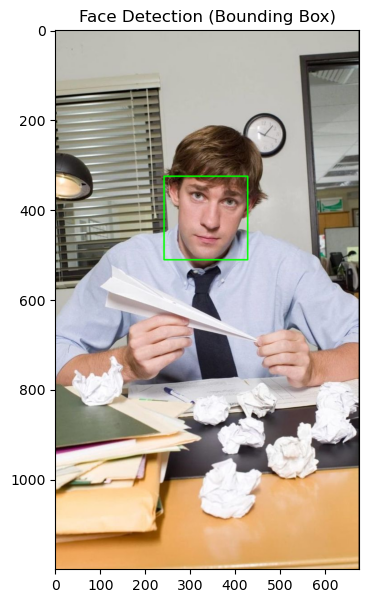

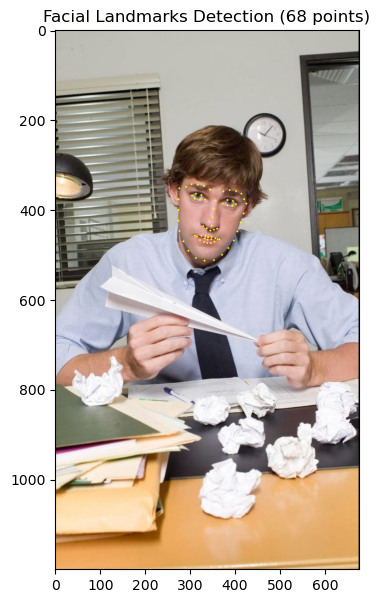

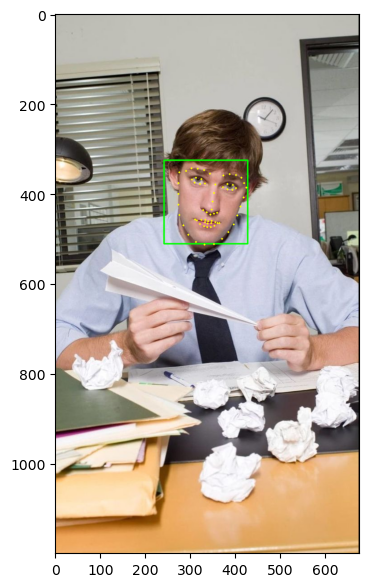

In [112]:
# 이미지 로드
img_path = os.path.join(home_dir, '/home/jovyan/work/AIFFEL_quest_eng/Computer_Vision/CV01/camera_sticker/models/5.jpg')
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_show = img_bgr.copy()

# dlib 얼굴 검출기 (HOG 기반)
detector_hog = dlib.get_frontal_face_detector()

# 얼굴 검출
dlib_rects = detector_hog(img_rgb, 1)

# 검출된 얼굴에 bounding box 그리기
for dlib_rect in dlib_rects:
    l = dlib_rect.left()
    t = dlib_rect.top()
    r = dlib_rect.right()
    b = dlib_rect.bottom()
    cv2.rectangle(img_show, (l, t), (r, b), (0, 255, 0), 2, cv2.LINE_AA)

# 얼굴 bounding box
plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.title('Face Detection (Bounding Box)')
plt.show()

model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')
landmark_predictor = dlib.shape_predictor(model_path)

# 랜드마크 검출
list_landmarks = []
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    list_landmarks.append(list_points)

# 랜드마크 그리기
img_show2 = img_bgr.copy()
for landmark in list_landmarks:
    for idx, point in enumerate(landmark):
        cv2.circle(img_show2, point, 2, (0, 255, 255), -1)

# 랜드마크 결과 출력
plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(img_show2, cv2.COLOR_BGR2RGB))
plt.title('Facial Landmarks Detection (68 points)')
plt.show()

# Bounding box + 랜드마크 함께 표시
img_show3 = img_bgr.copy()
for dlib_rect in dlib_rects:
    l = dlib_rect.left()
    t = dlib_rect.top()
    r = dlib_rect.right()
    b = dlib_rect.bottom()
    cv2.rectangle(img_show3, (l, t), (r, b), (0, 255, 0), 2, cv2.LINE_AA)

for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show3, point, 2, (0, 255, 255), -1)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(img_show3, cv2.COLOR_BGR2RGB))
plt.show()

### 2-2. 스티커 적용 위치 확인하기

얼굴 너비: 187
수염 스티커 크기: 280 x 280
수염 적용 위치: x=205, y=306
코 끝 위치 (landmark 30): [345 446]


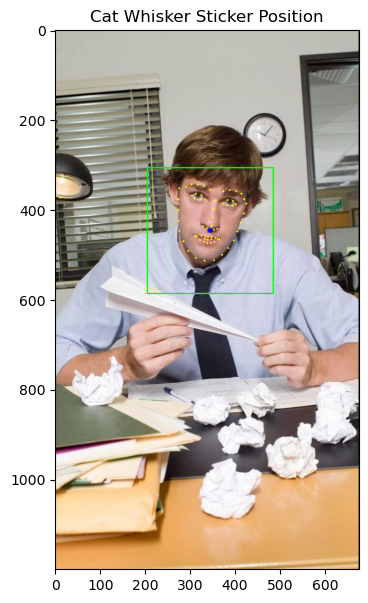

In [113]:
# NumPy 배열로 변환 (첫 번째 얼굴 사용)
landmarks = np.array(list_landmarks[0])

# 고양이 수염 위치 계산
# 코 끝 (landmark 33번)을 기준으로 수염 위치 설정
nose_tip = landmarks[33]

# 얼굴 너비 계산 (bounding box 사용)
dlib_rect = dlib_rects[0]
face_width = dlib_rect.width()

# 수염 스티커 크기 설정 (얼굴 너비의 1.5배)
sticker_width = int(face_width * 1.5)
sticker_height = int(face_width * 1.5)

# 수염 위치 계산 (코 끝을 중심으로)
x = nose_tip[0] - sticker_width // 2
y = nose_tip[1] - sticker_height // 2

print(f"얼굴 너비: {face_width}")
print(f"수염 스티커 크기: {sticker_width} x {sticker_height}")
print(f"수염 적용 위치: x={x}, y={y}")
print(f"코 끝 위치 (landmark 30): {nose_tip}")

# 위치 확인을 위한 시각화
img_show_position = img_bgr.copy()

# 얼굴 랜드마크 그리기
for point in landmarks:
    cv2.circle(img_show_position, tuple(point), 2, (0, 255, 255), -1)

# 코 끝 강조 표시 (빨간색)
cv2.circle(img_show_position, tuple(nose_tip), 5, (0, 0, 255), -1)

# 수염이 적용될 영역 표시 (초록색 사각형)
cv2.rectangle(img_show_position, (x, y), (x + sticker_width, y + sticker_height), (0, 255, 0), 2)

# 중심점 표시
center_x = x + sticker_width // 2
center_y = y + sticker_height // 2
cv2.circle(img_show_position, (center_x, center_y), 5, (255, 0, 0), -1)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(img_show_position, cv2.COLOR_BGR2RGB))
plt.title('Cat Whisker Sticker Position')
plt.show()

### 2-3. 스티커 적용하기

스티커 shape: (512, 512, 4)


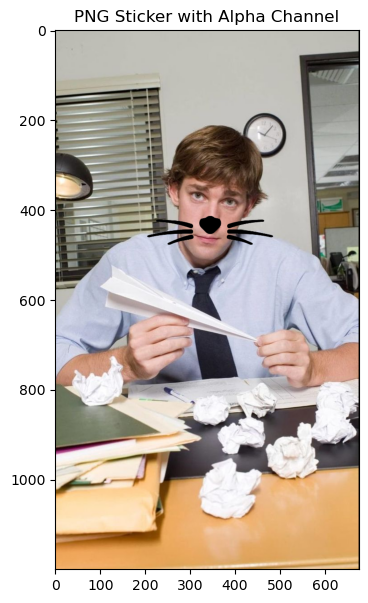

In [114]:
# 스티커 적용하기

# PNG 파일 로드 (알파 채널 포함)
sticker_path = os.path.join(home_dir, '/home/jovyan/work/AIFFEL_quest_eng/Computer_Vision/CV01/camera_sticker/images/cat-whiskers.png')
img_sticker = cv2.imread(sticker_path, cv2.IMREAD_UNCHANGED)

print(f"스티커 shape: {img_sticker.shape}")  # (height, width, 4) 확인

# 스티커 크기 조정
img_sticker_resized = cv2.resize(img_sticker, (sticker_width, sticker_height))

# BGR과 Alpha 분리
sticker_bgr = img_sticker_resized[:, :, :3]  # 색상 (BGR)
sticker_alpha = img_sticker_resized[:, :, 3]  # 투명도 (0~255)

# 결과 이미지 준비
img_result = img_bgr.copy()

# 경계 처리
refined_x = x
refined_y = y

if refined_x < 0:
    sticker_bgr = sticker_bgr[:, -refined_x:]
    sticker_alpha = sticker_alpha[:, -refined_x:]
    refined_x = 0
if refined_y < 0:
    sticker_bgr = sticker_bgr[-refined_y:, :]
    sticker_alpha = sticker_alpha[-refined_y:, :]
    refined_y = 0

# 이미지 경계 처리
img_h, img_w = img_result.shape[:2]
sticker_h, sticker_w = sticker_bgr.shape[:2]

if refined_y + sticker_h > img_h:
    sticker_bgr = sticker_bgr[:img_h - refined_y, :]
    sticker_alpha = sticker_alpha[:img_h - refined_y, :]
if refined_x + sticker_w > img_w:
    sticker_bgr = sticker_bgr[:, :img_w - refined_x]
    sticker_alpha = sticker_alpha[:, :img_w - refined_x]


# 최종 크기
sticker_h, sticker_w = sticker_bgr.shape[:2]
sticker_area = img_result[refined_y:refined_y+sticker_h, refined_x:refined_x+sticker_w]

# Alpha 채널을 0~1 범위로 정규화
alpha_mask = sticker_alpha[:, :, np.newaxis] / 255.0

# Alpha 블렌딩: 원본 * (1-알파) + 스티커 * 알파
img_result[refined_y:refined_y+sticker_h, refined_x:refined_x+sticker_w] = \
    (sticker_area * (1 - alpha_mask) + sticker_bgr * alpha_mask).astype(np.uint8)

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
plt.title('PNG Sticker with Alpha Channel')
plt.show()

## 3. 문제점 찾아보기 

### 3-1. 옆모습의 사진은 인식이 될까?

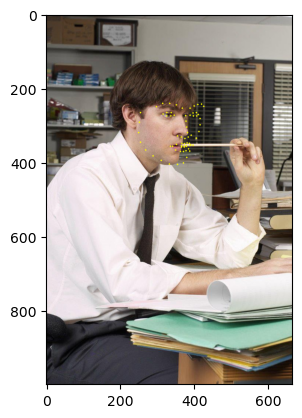

(187, 187, 3)
얼굴 각도: 0.27도
왕관 위치: x=287, y=41, 크기=187x187


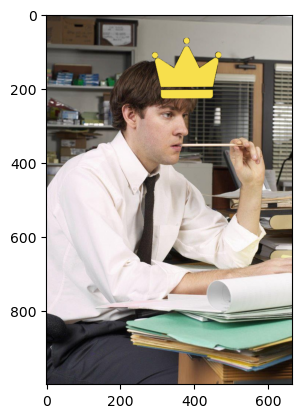

In [104]:
img_path = '/home/jovyan/work/AIFFEL_quest_eng/Computer_Vision/CV01/camera_sticker/models/6.jpg'
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_show = img_bgr.copy()

# 얼굴 검출
detector_hog = dlib.get_frontal_face_detector()
dlib_rects = detector_hog(img_rgb, 1)

# 랜드마크 검출
# home_dir 변수가 정의되어 있다고 가정하거나 절대 경로를 사용하세요.
model_path = os.path.join(os.getenv('HOME', '/home/jovyan'), 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')
landmark_predictor = dlib.shape_predictor(model_path)

list_landmarks = []
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    list_landmarks.append(list_points)

# 랜드마크 표시 (확인용)
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

# 왕관 적용은 원본 이미지에 (랜드마크 없이)
sticker_path = os.path.join(home_dir, 'work/camera_sticker/images/king.png')
img_sticker = cv2.imread(sticker_path)
img_sticker = cv2.resize(img_sticker, (w,h))
print (img_sticker.shape)


# 첫 번째 검출된 얼굴에 대해 처리
if len(list_landmarks) > 0:
    landmarks = np.array(list_landmarks[0])

    # 얼굴 각도 계산 (get_face_angle 함수가 정의되어 있어야 함)
    angle = get_face_angle(landmarks)
    print(f"얼굴 각도: {angle:.2f}도")

    # 위치 계산: 양쪽 눈썹 중심 사용 (좌우 중앙 맞춤)
    left_eyebrow_center = landmarks[19:22].mean(axis=0).astype(int)   # 왼쪽 눈썹
    right_eyebrow_center = landmarks[22:27].mean(axis=0).astype(int)  # 오른쪽 눈썹
    eyebrow_center = ((left_eyebrow_center + right_eyebrow_center) / 2).astype(int)

    # 크기 계산: 얼굴 전체 너비 사용
    face_width = dlib_rects[0].width()
    w = face_width
    h = w

    # 왕관 위치: 눈썹 중심 기준, 위로 배치
    refined_x = eyebrow_center[0] - w // 2
    refined_y = eyebrow_center[1] - int(h * 1.1)

    print(f"왕관 위치: x={refined_x}, y={refined_y}, 크기={w}x{h}")

    # 스티커 회전 (rotate_sticker 함수가 정의되어 있어야 함)
    # img_sticker는 사전에 로드되어 있어야 합니다.
    img_sticker_rotated = rotate_sticker(img_sticker, angle)

    # 회전된 스티커를 리사이즈
    img_sticker_resized = cv2.resize(img_sticker_rotated, (w, h))

    # 경계 처리 (이미지 밖으로 나가는 경우)
    if refined_y < 0:
        img_sticker_resized = img_sticker_resized[-refined_y:, :]
        refined_y = 0
    if refined_x < 0:
        img_sticker_resized = img_sticker_resized[:, -refined_x:]
        refined_x = 0

    # 스티커 적용을 위한 영역(ROI) 설정
    sticker_h, sticker_w = img_sticker_resized.shape[:2]
    sticker_area = img_bgr[refined_y:refined_y + sticker_h, refined_x:refined_x + sticker_w]

    # --- 핵심 수정 부분: 채널 수 맞추기 ---
    # img_sticker_resized가 4채널(RGBA)일 경우, BGR(3채널)만 추출합니다.
    if img_sticker_resized.shape[2] == 4:
        img_sticker_color = img_sticker_resized[:, :, :3]
    else:
        img_sticker_color = img_sticker_resized

    # 크기 체크 후 적용
    if sticker_area.shape[:2] == img_sticker_color.shape[:2]:
        img_bgr[refined_y:refined_y + sticker_h, refined_x:refined_x + sticker_w] = \
            np.where(img_sticker_color == 0, sticker_area, img_sticker_color).astype(np.uint8)
    else:
        # 크기 불일치 시 조정 (이미지 경계에 걸친 경우)
        h_min = min(sticker_area.shape[0], img_sticker_color.shape[0])
        w_min = min(sticker_area.shape[1], img_sticker_color.shape[1])
        
        img_bgr[refined_y:refined_y + h_min, refined_x:refined_x + w_min] = \
            np.where(img_sticker_color[:h_min, :w_min] == 0, 
                     sticker_area[:h_min, :w_min], 
                     img_sticker_color[:h_min, :w_min]).astype(np.uint8)

# 최종 결과 출력
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.show()

옆모습에서는 중심점을 잡아놓아도 '왕관'이미지의 위치를 정확하게는 잡지 못한다. 이를 해결할 수 있는 방안은 없을까?

검출된 얼굴 수: 1, 회전 각도: 0도


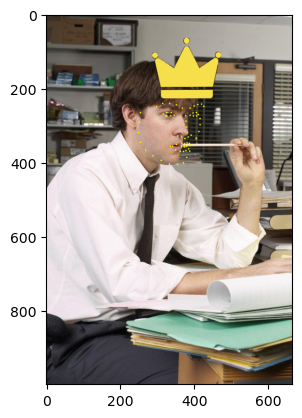

(187, 187, 3)
얼굴 각도: 0.27도
왕관 위치: x=287, y=41, 크기=187x187


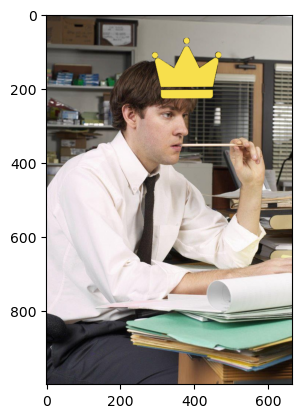

In [105]:
# 얼굴 검출
detector_hog = dlib.get_frontal_face_detector()

def detect_rotated_faces(img):
    angles = [0, 90, 180, 270]
    all_faces = []
    
    for angle in angles:
        # 이미지 회전
        if angle == 90:
            img_rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
        elif angle == 180:
            img_rotated = cv2.rotate(img, cv2.ROTATE_180)
        elif angle == 270:
            img_rotated = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
        else:
            img_rotated = img
        
        # 얼굴 검출
        faces = detector_hog(img_rotated, 1)
        
        if len(faces) > 0:
            return faces, angle
    
    return [], 0

# 새로운 코드 사용
dlib_rects, detected_angle = detect_rotated_faces(img_rgb)
print(f"검출된 얼굴 수: {len(dlib_rects)}, 회전 각도: {detected_angle}도")

# 이미지도 같은 각도로 회전시켜야 함
if detected_angle == 90:
    img_rgb = cv2.rotate(img_rgb, cv2.ROTATE_90_CLOCKWISE)
    img_bgr = cv2.rotate(img_bgr, cv2.ROTATE_90_CLOCKWISE)
elif detected_angle == 180:
    img_rgb = cv2.rotate(img_rgb, cv2.ROTATE_180)
    img_bgr = cv2.rotate(img_bgr, cv2.ROTATE_180)
elif detected_angle == 270:
    img_rgb = cv2.rotate(img_rgb, cv2.ROTATE_90_COUNTERCLOCKWISE)
    img_bgr = cv2.rotate(img_bgr, cv2.ROTATE_90_COUNTERCLOCKWISE)

img_show = img_bgr.copy()

# 랜드마크 검출
model_path = os.path.join(home_dir, 'work/camera_sticker/models/shape_predictor_68_face_landmarks.dat')
landmark_predictor = dlib.shape_predictor(model_path)
list_landmarks = []
for dlib_rect in dlib_rects:
    points = landmark_predictor(img_rgb, dlib_rect)
    list_points = list(map(lambda p: (p.x, p.y), points.parts()))
    list_landmarks.append(list_points)

# 랜드마크 표시 (확인용)
for landmark in list_landmarks:
    for point in landmark:
        cv2.circle(img_show, point, 2, (0, 255, 255), -1)

img_show_rgb = cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB)
plt.imshow(img_show_rgb)
plt.show()

# 왕관 적용은 원본 이미지에 (랜드마크 없이)
sticker_path = os.path.join(home_dir, 'work/camera_sticker/images/king.png')
img_sticker = cv2.imread(sticker_path)
img_sticker = cv2.resize(img_sticker, (w,h))
print (img_sticker.shape)


# 첫 번째 검출된 얼굴에 대해 처리
if len(list_landmarks) > 0:
    landmarks = np.array(list_landmarks[0])

    # 얼굴 각도 계산 (get_face_angle 함수가 정의되어 있어야 함)
    angle = get_face_angle(landmarks)
    print(f"얼굴 각도: {angle:.2f}도")

    # 위치 계산: 양쪽 눈썹 중심 사용 (좌우 중앙 맞춤)
    left_eyebrow_center = landmarks[19:22].mean(axis=0).astype(int)   # 왼쪽 눈썹
    right_eyebrow_center = landmarks[22:27].mean(axis=0).astype(int)  # 오른쪽 눈썹
    eyebrow_center = ((left_eyebrow_center + right_eyebrow_center) / 2).astype(int)

    # 크기 계산: 얼굴 전체 너비 사용
    face_width = dlib_rects[0].width()
    w = face_width
    h = w

    # 왕관 위치: 눈썹 중심 기준, 위로 배치
    refined_x = eyebrow_center[0] - w // 2
    refined_y = eyebrow_center[1] - int(h * 1.1)

    print(f"왕관 위치: x={refined_x}, y={refined_y}, 크기={w}x{h}")

    # 스티커 회전 (rotate_sticker 함수가 정의되어 있어야 함)
    # img_sticker는 사전에 로드되어 있어야 합니다.
    img_sticker_rotated = rotate_sticker(img_sticker, angle)

    # 회전된 스티커를 리사이즈
    img_sticker_resized = cv2.resize(img_sticker_rotated, (w, h))

    # 경계 처리 (이미지 밖으로 나가는 경우)
    if refined_y < 0:
        img_sticker_resized = img_sticker_resized[-refined_y:, :]
        refined_y = 0
    if refined_x < 0:
        img_sticker_resized = img_sticker_resized[:, -refined_x:]
        refined_x = 0

    # 스티커 적용을 위한 영역(ROI) 설정
    sticker_h, sticker_w = img_sticker_resized.shape[:2]
    sticker_area = img_bgr[refined_y:refined_y + sticker_h, refined_x:refined_x + sticker_w]

    # --- 핵심 수정 부분: 채널 수 맞추기 ---
    # img_sticker_resized가 4채널(RGBA)일 경우, BGR(3채널)만 추출합니다.
    if img_sticker_resized.shape[2] == 4:
        img_sticker_color = img_sticker_resized[:, :, :3]
    else:
        img_sticker_color = img_sticker_resized

    # 크기 체크 후 적용
    if sticker_area.shape[:2] == img_sticker_color.shape[:2]:
        img_bgr[refined_y:refined_y + sticker_h, refined_x:refined_x + sticker_w] = \
            np.where(img_sticker_color == 0, sticker_area, img_sticker_color).astype(np.uint8)
    else:
        # 크기 불일치 시 조정 (이미지 경계에 걸친 경우)
        h_min = min(sticker_area.shape[0], img_sticker_color.shape[0])
        w_min = min(sticker_area.shape[1], img_sticker_color.shape[1])
        
        img_bgr[refined_y:refined_y + h_min, refined_x:refined_x + w_min] = \
            np.where(img_sticker_color[:h_min, :w_min] == 0, 
                     sticker_area[:h_min, :w_min], 
                     img_sticker_color[:h_min, :w_min]).astype(np.uint8)

# 최종 결과 출력
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.show()

In [106]:
# 얼굴 검출기
detector_hog = dlib.get_frontal_face_detector()

# 회전된 얼굴 검출 함수
def detect_rotated_faces(img, detector):
    angles = [0, 90, 180, 270]
    
    for angle in angles:
        # 이미지 회전
        if angle == 90:
            img_rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
        elif angle == 180:
            img_rotated = cv2.rotate(img, cv2.ROTATE_180)
        elif angle == 270:
            img_rotated = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
        else:
            img_rotated = img
        
        # 얼굴 검출
        faces = detector(img_rotated, 1)
        
        print(f"각도 {angle}도에서 검출된 얼굴 수: {len(faces)}")  # 디버깅
        
        if len(faces) > 0:
            print(f"✓ {angle}도에서 얼굴 검출 성공!")
            return faces, angle, img_rotated  # 회전된 이미지도 반환
    
    print("모든 각도에서 얼굴 검출 실패")
    return [], 0, img

# 사용
dlib_rects, detected_angle, img_rgb_rotated = detect_rotated_faces(img_rgb, detector_hog)
print(f"\n최종 결과: 검출된 얼굴 수 = {len(dlib_rects)}, 회전 각도 = {detected_angle}도")

# 검출에 성공한 경우, 회전된 이미지 사용
if len(dlib_rects) > 0:
    img_rgb = img_rgb_rotated
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    img_show = img_bgr.copy()
else:
    print("얼굴을 찾을 수 없습니다.")

각도 0도에서 검출된 얼굴 수: 1
✓ 0도에서 얼굴 검출 성공!

최종 결과: 검출된 얼굴 수 = 1, 회전 각도 = 0도


### 3-2. 소결

옆모습이 회전한 것임을 인식하려면 정면 사진을 참조하게 해야 하나..? 여러 의문점들을 남긴다. 허나 시간이 부족하여 여기서 '문제점 찾아보기'를 마무리 짓는다.